In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt

x = np.random.rand(100000, 1)
y = (2 * x + 5 + np.random.randn(100000, 1) * 0.1).flatten()

In [8]:
#Vectorized

class LinearRegression:
    def __init__(self):
        self.w = 0
        self.b = 0.0
        self.history = []

    def fit(self, x, y):
        m, n = x.shape
        self.w = np.zeros(n)
        self.b = 0.0
        a = 0.01
        
        for _ in range(1300):
            f = np.dot(x, self.w) + self.b
            error = f - y
            
            loss = (1 / (2 * m)) * np.sum(error**2)
            self.history.append(loss)
            
            dw = (1/m) * np.dot(x.T, error)
            db = (1/m) * np.sum(error)
            
            self.w -= a * dw
            self.b -= a * db

    def predict(self, x):
        return np.dot(x, self.w) + self.b

np.random.seed(42)


start_vec = time.time()
function = LinearRegression()
function.fit(x, y)
time_vec = time.time() - start_vec

print(f"Result: y = {function.w[0]:.2f}x + ({function.b:.2f})")

Result: y = 2.22x + (4.88)


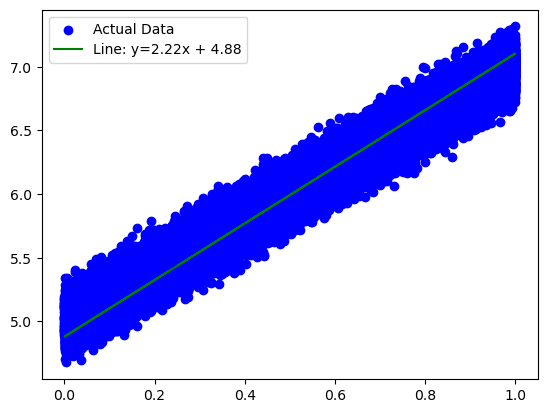

In [10]:
import matplotlib.pyplot as plt
y_line = function.predict(x)

# 4. Plotting
plt.scatter(x, y, color='blue', label='Actual Data')
plt.plot(x, y_line, color='green', label=f'Line: y={function.w[0]:.2f}x + {function.b:.2f}')
plt.legend()
plt.show()

In [4]:
#Looped
import numpy as np
import time

class LinearRegression:
    def __init__(self):
        self.w = 0.0
        self.b = 0.0

    def fit(self, x, y):
        m = len(y)

        for _ in range(1300):
            dw = 0.0
            db = 0.0

            for i in range(m):
                xi = x[i][0]
                yi = y[i]
                f = xi * self.w + self.b
                
                error = f - yi
                
                dw += error * xi
                db += error
            
            self.w -= 0.01 * (dw / m)
            self.b -= 0.01 * (db /m)
            
        end_loop = time.time()

start_loop = time.time()

model = LinearRegression()
model.fit(x, y)

time_loop = time.time() - start_loop


print(f"Result: y = {model.w:.2f}x + {model.b:.2f}")


Result: y = 2.22x + 4.88


In [9]:
#Speed
speed =  time_loop / time_vec 

print(f"The Vectorized version is {speed:.2f}x faster than the Looped version.")

The Vectorized version is 51.04x faster than the Looped version.


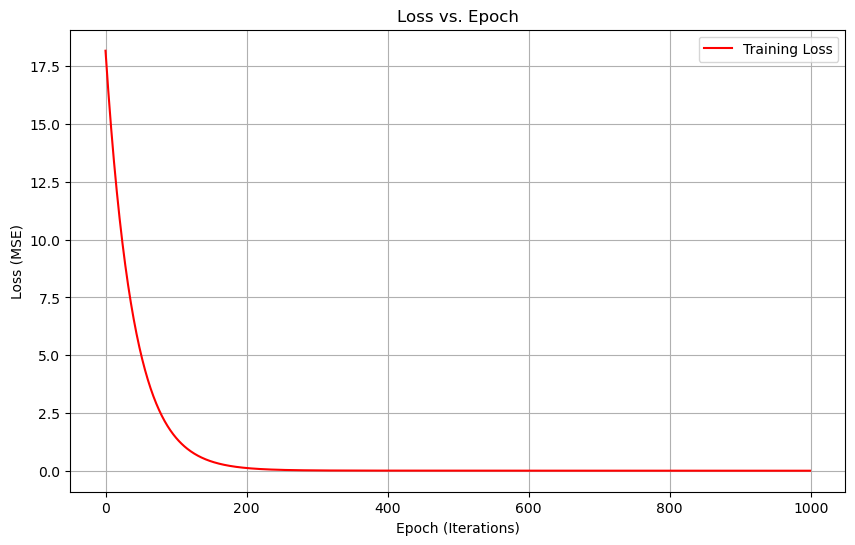

In [33]:
# Loss vs Epoch Graph

plt.figure(figsize=(10, 6))
plt.plot(function.history, label='Training Loss', color='red')
plt.title('Loss vs. Epoch')
plt.xlabel('Epoch (Iterations)')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()